In [111]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

# S&P500 지수 다운로드 (티커: ^GSPC)
data = yf.download("^GSPC", start="2000-01-01", end="2025-10-01")
returns = data.loc[:, pd.IndexSlice[:, "^GSPC", :]]
returns.columns = returns.columns.droplevel(1)  # ^GSPC 레벨 제거

# 로그 변화율 계산
returns["log_change"] = np.log(returns["Close"] / returns["Close"].shift(1))

# 비율 변화량 계산 (pct_change 사용)
returns["change"] = returns["Close"].pct_change()

# change를 logchange로부터 복구
returns["test"] = np.exp(returns["log_change"]) - 1

# 불필요한 NaN 값 제거
returns = returns.dropna()

# 필요한 열만 선택
returns = returns[["Close", "change", "log_change", "test"]]

# 데이터 분할 기준일: 가장 최신 날짜 기준으로 일주일 전
split_date = returns.index[-7]

# 학습 데이터: 일주일 전까지
train_data = returns[returns.index < split_date]

# 검증 데이터: 일주일 동안
test_data = returns[returns.index >= split_date]

print(f"학습 데이터 기간: {train_data.index.min()} ~ {train_data.index.max()}")
print(f"검증 데이터 기간: {test_data.index.min()} ~ {test_data.index.max()}")

print(returns)
print(train_data)
print(test_data)

[*********************100%***********************]  1 of 1 completed

학습 데이터 기간: 2000-01-04 00:00:00 ~ 2025-04-30 00:00:00
검증 데이터 기간: 2025-05-01 00:00:00 ~ 2025-05-09 00:00:00
Price             Close    change  log_change      test
Date                                                   
2000-01-04  1399.420044 -0.038345   -0.039099 -0.038345
2000-01-05  1402.109985  0.001922    0.001920  0.001922
2000-01-06  1403.449951  0.000956    0.000955  0.000956
2000-01-07  1441.469971  0.027090    0.026730  0.027090
2000-01-10  1457.599976  0.011190    0.011128  0.011190
...                 ...       ...         ...       ...
2025-05-05  5650.379883 -0.006382   -0.006402 -0.006382
2025-05-06  5606.910156 -0.007693   -0.007723 -0.007693
2025-05-07  5631.279785  0.004346    0.004337  0.004346
2025-05-08  5663.939941  0.005800    0.005783  0.005800
2025-05-09  5659.910156 -0.000711   -0.000712 -0.000711

[6376 rows x 4 columns]
Price             Close    change  log_change      test
Date                                                   
2000-01-04  1399.420044 -0.03

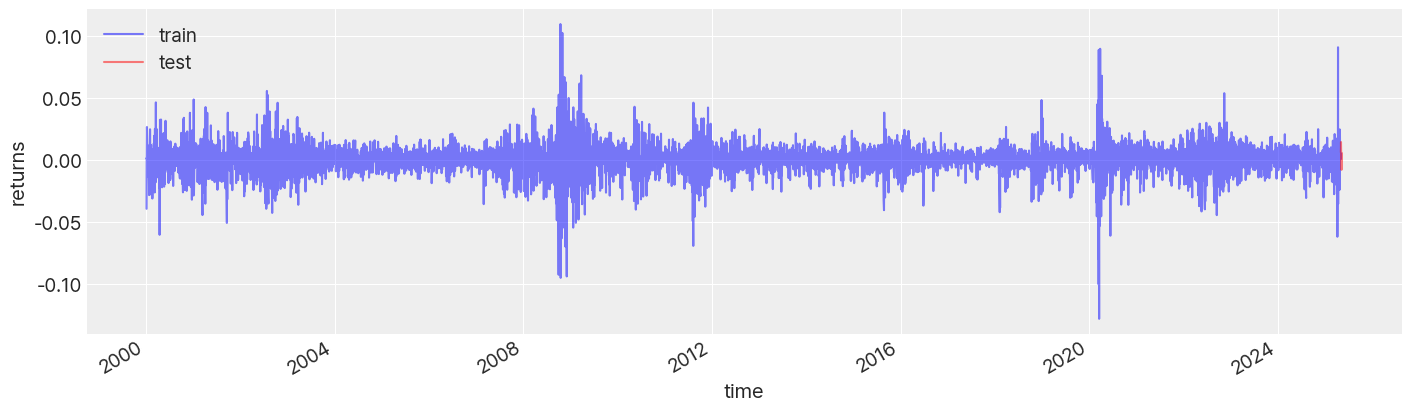

In [112]:
fig, ax = plt.subplots(figsize=(14, 4))
train_data.plot(y="log_change", label="train", ax=ax, color="blue", alpha=0.5)
test_data.plot(y="log_change", label="test", ax=ax, color="red", alpha=0.5)
ax.set(xlabel="time", ylabel="returns")
ax.legend();

In [113]:
def make_stochastic_volatility_model(data):
    with pm.Model(coords={"time": data.index.values}) as model:
        step_size = pm.Exponential("step_size", 10)
        log_volatility = pm.GaussianRandomWalk("log_volatility", sigma=step_size, dims="time")
        volatility = pm.Deterministic("volatility", pm.math.exp(log_volatility), dims="time")
        # lam = pm.Deterministic("lambda", pm.math.exp(-2 * log_volatility))

        # Jump 관련 매개변수 정의 (로그 스케일에서 정의)
        # jump_prob = pm.Beta("jump_prob", alpha=2, beta=10)
        log_jump_size_mean = pm.Normal("log_jump_size_mean", mu=0, sigma=0.05)
        log_jump_size_sd = pm.HalfNormal("log_jump_size_sd", sigma=0.05)

        # 점프 여부 인디케이터
        jump_indicator = pm.Bernoulli("jump_indicator", p=0.0137, dims="time")
        log_jump_size = pm.Normal("log_jump_size", mu=log_jump_size_mean, sigma=log_jump_size_sd, dims="time")

        # 로그 스케일에서 점프 효과 추가
        log_volatility_with_jump = log_volatility + jump_indicator * log_jump_size

        sigma = pm.Deterministic("sigma", pm.math.exp(-log_volatility_with_jump))
        nu = pm.Exponential("nu", 0.1)
        pm.StudentT(
            "returns", nu=nu, sigma=sigma , observed=data["log_change"], dims="time"
        ) 
    return model

stochastic_vol_model = make_stochastic_volatility_model(train_data)

/opt/conda/envs/bap3/lib/python3.11/site-packages/pymc/distributions/timeseries.py:297: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(


In [114]:
# def make_stochastic_volatility_model(data):
#     with pm.Model(coords={"time": data.index.values}) as model:
#         step_size = pm.Exponential("step_size", 10)
#         log_volatility = pm.GaussianRandomWalk("log_volatility", sigma=step_size, dims="time")
#         volatility = pm.Deterministic("volatility", pm.math.exp(log_volatility), dims="time")
#         lam = pm.Deterministic("lambda", pm.math.exp(-2 * log_volatility))
#         nu = pm.Exponential("nu", 0.1)
#         pm.StudentT(
#             "returns", nu=nu, lam=lam, observed=data["log_change"], dims="time"
#         )
#     return model


# stochastic_vol_model = make_stochastic_volatility_model(train_data)

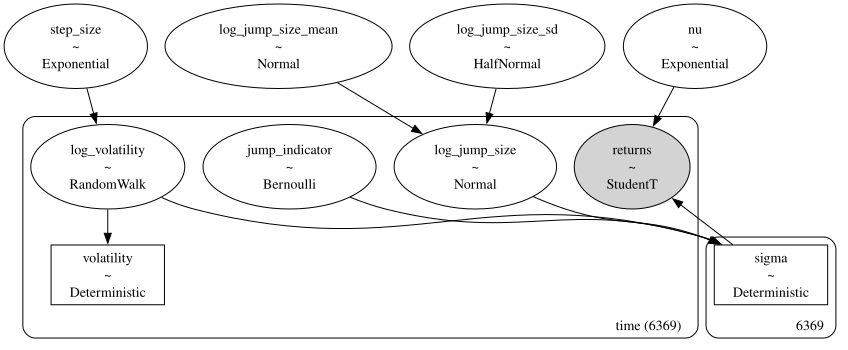

In [115]:
pm.model_to_graphviz(stochastic_vol_model)

In [116]:
rng = np.random.default_rng(1234)
az.style.use("arviz-darkgrid")

In [117]:
with stochastic_vol_model:
    idata = pm.sample_prior_predictive(500, random_seed=rng)

prior_predictive = idata.prior_predictive.stack(pooled_chain=("chain", "draw"))

Sampling: [jump_indicator, log_jump_size, log_jump_size_mean, log_jump_size_sd, log_volatility, nu, returns, step_size]


In [118]:
idata

Inference data with groups:
	> prior
	> prior_predictive
	> observed_data

In [119]:
prior_predictive

<xarray.Dataset> Size: 26MB
Dimensions:       (time: 6369, pooled_chain: 500)
Coordinates:
  * time          (time) datetime64[ns] 51kB 2000-01-04 ... 2025-04-30
  * pooled_chain  (pooled_chain) object 4kB MultiIndex
  * chain         (pooled_chain) int64 4kB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
  * draw          (pooled_chain) int64 4kB 0 1 2 3 4 5 ... 495 496 497 498 499
Data variables:
    returns       (time, pooled_chain) float64 25MB -2.273e-73 ... 5.706e-19
Attributes:
    created_at:                 2025-05-10T03:33:29.404976+00:00
    arviz_version:              0.21.0
    inference_library:          pymc
    inference_library_version:  5.20.1

In [120]:
prior_predictive["returns"].shape

(6369, 500)

/tmp/ipykernel_8855/2910044826.py:9: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  plt.plot(subset.time, subset[:, i], label=label, color="g",
/tmp/ipykernel_8855/2910044826.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


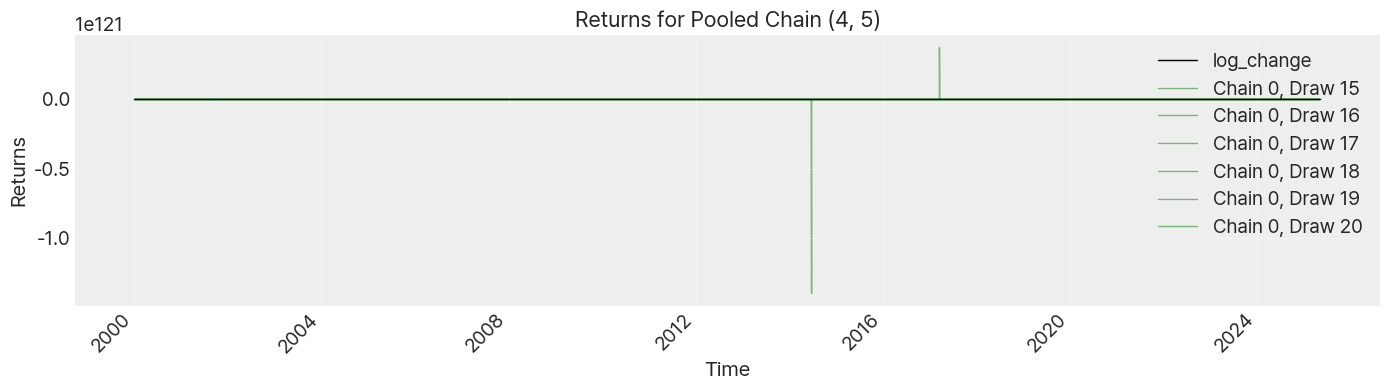

In [121]:

subset = prior_predictive["returns"].isel(pooled_chain=slice(15, 21, None))

# 그래프 그리기
fig, ax = plt.subplots(figsize=(14, 4))
returns["log_change"].plot(ax=ax, lw=1, color="black")
for i in range(subset.pooled_chain.size):
    chain, draw = subset.pooled_chain.values[i]
    label = f"Chain {chain}, Draw {draw}"
    plt.plot(subset.time, subset[:, i], label=label, color="g",
    alpha=0.5,
    lw=1,
    zorder=-10,)

plt.title("Returns for Pooled Chain (4, 5)")
plt.xlabel("Time")
plt.ylabel("Returns")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [122]:
# with stochastic_vol_model:
#     pm.sample(3000, random_seed=rng, target_accept=0.95, idata_kwargs={"log_likelihood": True})


In [123]:
with stochastic_vol_model:
    idata.extend(pm.sample(3000, random_seed=rng, target_accept=0.95, idata_kwargs={"log_likelihood": True}))

posterior = idata.posterior.stack(pooled_chain=("chain", "draw"))
# posterior["volatility"] = np.exp(posterior["volatility"])

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [step_size, log_volatility, log_jump_size_mean, log_jump_size_sd, log_jump_size, nu]
>BinaryGibbsMetropolis: [jump_indicator]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 6357 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [124]:
from datetime import datetime
import arviz as az

# 현재 날짜와 시간
now = datetime.now()
formatted_time = now.strftime("%Y%m%d%H%M")  # 202505081200 형식

# 파일 저장
az.to_netcdf(idata, f"trace-{formatted_time}.nc")

'trace-202505100539.nc'

In [125]:
posterior["volatility"]

<xarray.DataArray 'volatility' (time: 6369, pooled_chain: 12000)> Size: 611MB
array([[94.01247787, 64.83804204, 92.34804845, ..., 76.80680099,
        76.47756951, 67.55679896],
       [93.05129626, 69.18309564, 98.14902872, ..., 71.00049696,
        73.39849333, 74.87260929],
       [86.42876393, 67.3155693 , 99.30435117, ..., 89.05449271,
        77.88685847, 71.97288279],
       ...,
       [40.04893534, 71.11068416, 42.03787651, ..., 50.17660608,
        38.06120622, 45.22358847],
       [41.12436055, 72.82003192, 41.78751005, ..., 46.96279066,
        40.50617116, 44.29170405],
       [39.35437025, 69.04111354, 40.6858859 , ..., 49.74581148,
        39.3718909 , 44.14715458]])
Coordinates:
  * time          (time) datetime64[ns] 51kB 2000-01-04 ... 2025-04-30
  * pooled_chain  (pooled_chain) object 96kB MultiIndex
  * chain         (pooled_chain) int64 96kB 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3
  * draw          (pooled_chain) int64 96kB 0 1 2 3 4 ... 2996 2997 2998 2999

In [126]:
posterior

<xarray.Dataset> Size: 3GB
Dimensions:             (time: 6369, pooled_chain: 12000, sigma_dim_0: 6369)
Coordinates:
  * time                (time) datetime64[ns] 51kB 2000-01-04 ... 2025-04-30
  * sigma_dim_0         (sigma_dim_0) int64 51kB 0 1 2 3 ... 6365 6366 6367 6368
  * pooled_chain        (pooled_chain) object 96kB MultiIndex
  * chain               (pooled_chain) int64 96kB 0 0 0 0 0 0 0 ... 3 3 3 3 3 3
  * draw                (pooled_chain) int64 96kB 0 1 2 3 ... 2997 2998 2999
Data variables:
    log_volatility      (time, pooled_chain) float64 611MB 4.543 4.172 ... 3.788
    log_jump_size_mean  (pooled_chain) float64 96kB -0.003424 ... 0.04305
    jump_indicator      (time, pooled_chain) int64 611MB 0 0 0 0 0 ... 0 0 0 0 0
    log_jump_size       (time, pooled_chain) float64 611MB 0.00659 ... 0.04601
    step_size           (pooled_chain) float64 96kB 0.07907 0.08 ... 0.07458
    log_jump_size_sd    (pooled_chain) float64 96kB 0.1811 0.1798 ... 0.06542
    nu                  (pooled_chain) float64 96kB 9.975 13.22 ... 16.92 14.15
    volatility          (time, pooled_chain) float64 611MB 94.01 64.84 ... 44.15
    sigma               (sigma_dim_0, pooled_chain) float64 611MB 0.01064 ......
Attributes:
    created_at:                 2025-05-10T05:19:45.046561+00:00
    arviz_version:              0.21.0
    inference_library:          pymc
    inference_library_version:  5.20.1
    sampling_time:              6357.369745492935
    tuning_steps:               1000

In [127]:
idata

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> prior
	> prior_predictive
	> observed_data

In [128]:
summary = az.summary(idata)
summary[summary["r_hat"] > 1.0].sort_values("r_hat", ascending=False)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
log_jump_size_sd,0.106,0.030,0.059,0.167,0.011,0.005,8.0,19.0,1.47
log_jump_size_mean,-0.006,0.052,-0.112,0.089,0.012,0.006,20.0,55.0,1.14
step_size,0.079,0.005,0.069,0.089,0.001,0.000,90.0,167.0,1.05
log_jump_size[2006-07-27T00:00:00.000000000],-0.006,0.122,-0.241,0.230,0.011,0.010,117.0,154.0,1.03
log_jump_size[2017-02-27T00:00:00.000000000],-0.005,0.125,-0.244,0.236,0.011,0.011,132.0,173.0,1.03
...,...,...,...,...,...,...,...,...,...
nu,15.171,3.348,9.882,21.520,0.167,0.089,329.0,721.0,1.01
volatility[2000-01-13T00:00:00.000000000],72.660,14.286,47.093,99.852,0.441,0.188,1041.0,2694.0,1.01
volatility[2000-01-14T00:00:00.000000000],73.555,14.380,47.928,101.259,0.447,0.191,1021.0,2592.0,1.01
volatility[2000-01-18T00:00:00.000000000],74.294,14.410,47.566,100.870,0.448,0.185,1013.0,2435.0,1.01


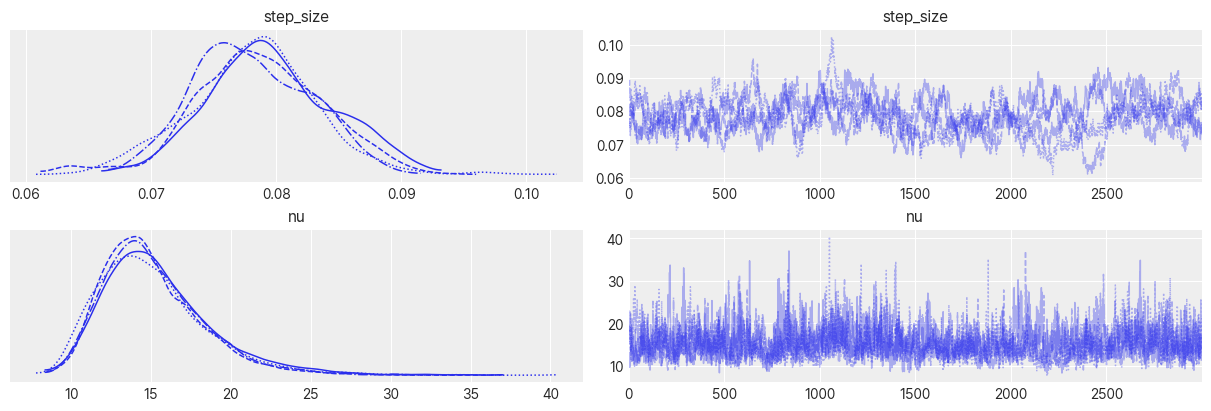

In [129]:
az.plot_trace(idata, var_names=["step_size", "nu"]);

In [130]:
az.loo(idata)

/opt/conda/envs/bap3/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 12000 posterior samples and 6369 observations log-likelihood matrix.

         Estimate       SE
elpd_loo 20747.90    75.27
p_loo      301.21        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     6368  100.0%
   (0.70, 1]   (bad)         1    0.0%
   (1, Inf)   (very bad)    0    0.0%

In [131]:
with stochastic_vol_model:
    posterior_predictive = pm.sample_posterior_predictive(idata, random_seed=rng)


Sampling: [returns]


Output()

In [132]:
posterior_predictive

Inference data with groups:
	> posterior_predictive
	> observed_data

In [133]:
posterior_predictive.posterior_predictive["returns"].shape

(4, 3000, 6369)

(-0.05, 0.05)

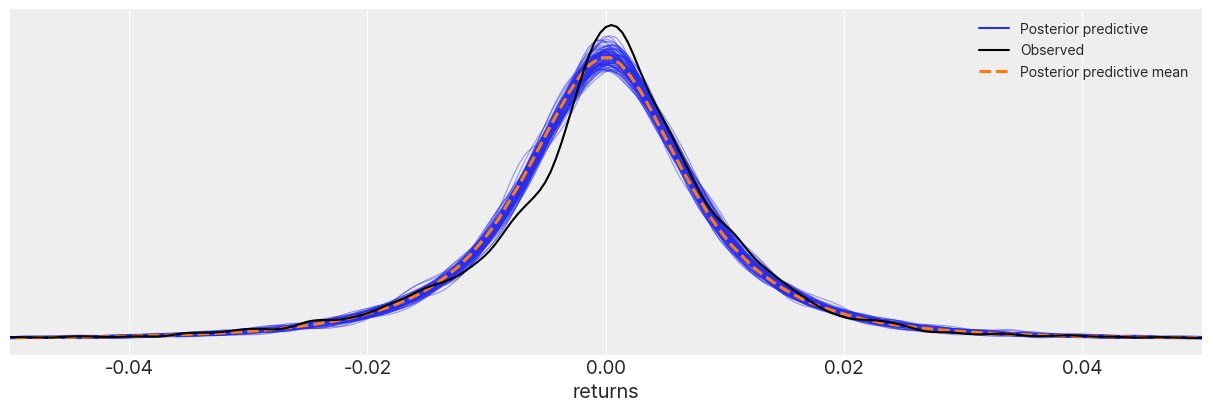

In [134]:
fig, ax = plt.subplots(figsize=(12, 4))
az.plot_ppc(posterior_predictive, num_pp_samples=100, ax=ax, kind="kde", alpha=0.5);
ax.set_xlim(-0.05, 0.05)

<Axes: title={'center': 'returns'}>

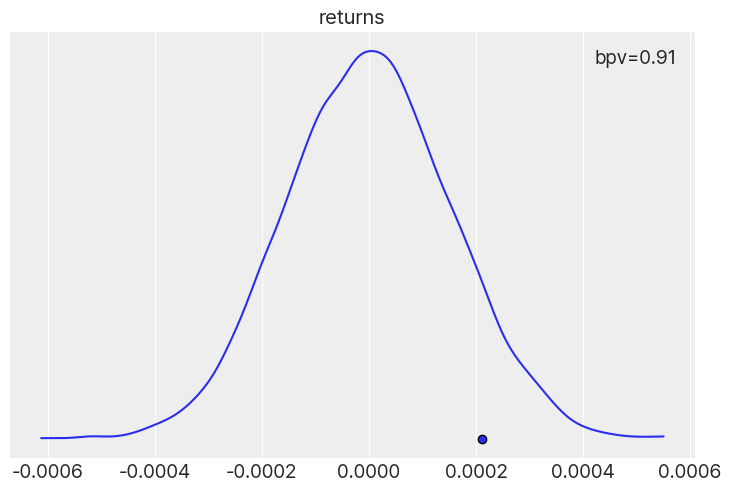

In [135]:
az.plot_bpv(posterior_predictive, kind="t_stat", t_stat="mean")

In [136]:
posterior

<xarray.Dataset> Size: 3GB
Dimensions:             (time: 6369, pooled_chain: 12000, sigma_dim_0: 6369)
Coordinates:
  * time                (time) datetime64[ns] 51kB 2000-01-04 ... 2025-04-30
  * sigma_dim_0         (sigma_dim_0) int64 51kB 0 1 2 3 ... 6365 6366 6367 6368
  * pooled_chain        (pooled_chain) object 96kB MultiIndex
  * chain               (pooled_chain) int64 96kB 0 0 0 0 0 0 0 ... 3 3 3 3 3 3
  * draw                (pooled_chain) int64 96kB 0 1 2 3 ... 2997 2998 2999
Data variables:
    log_volatility      (time, pooled_chain) float64 611MB 4.543 4.172 ... 3.788
    log_jump_size_mean  (pooled_chain) float64 96kB -0.003424 ... 0.04305
    jump_indicator      (time, pooled_chain) int64 611MB 0 0 0 0 0 ... 0 0 0 0 0
    log_jump_size       (time, pooled_chain) float64 611MB 0.00659 ... 0.04601
    step_size           (pooled_chain) float64 96kB 0.07907 0.08 ... 0.07458
    log_jump_size_sd    (pooled_chain) float64 96kB 0.1811 0.1798 ... 0.06542
    nu                  (pooled_chain) float64 96kB 9.975 13.22 ... 16.92 14.15
    volatility          (time, pooled_chain) float64 611MB 94.01 64.84 ... 44.15
    sigma               (sigma_dim_0, pooled_chain) float64 611MB 0.01064 ......
Attributes:
    created_at:                 2025-05-10T05:19:45.046561+00:00
    arviz_version:              0.21.0
    inference_library:          pymc
    inference_library_version:  5.20.1
    sampling_time:              6357.369745492935
    tuning_steps:               1000

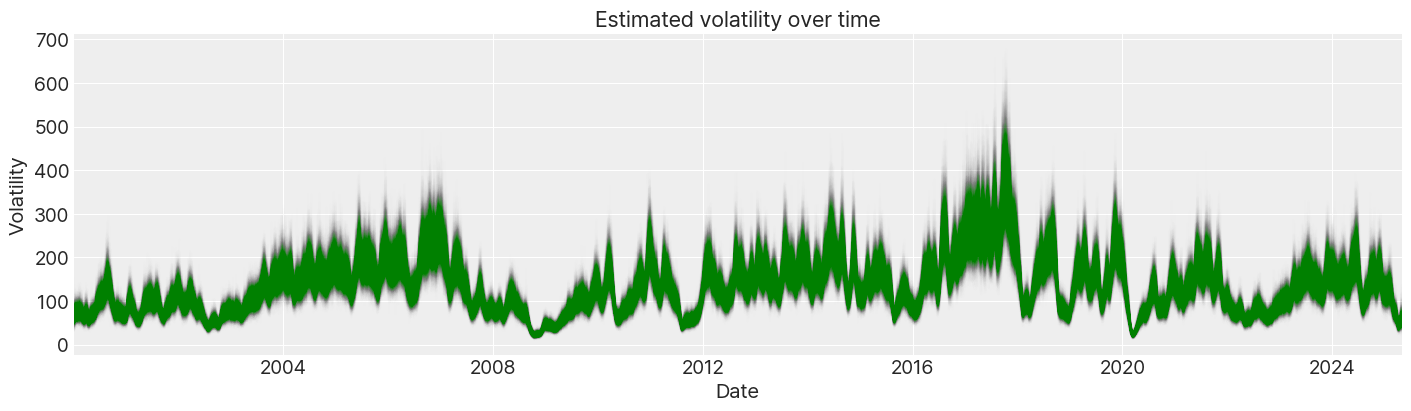

In [137]:
fig, ax = plt.subplots(figsize=(14, 4))

y_vals = posterior["volatility"].isel(pooled_chain=slice(None, None, 10))
x_vals = y_vals.time.astype(np.datetime64)

plt.plot(x_vals, y_vals, "g", alpha=0.002)
ax.set_xlim(x_vals.min(), x_vals.max())
# ax.set_ylim(bottom=0)
ax.set(title="Estimated volatility over time", xlabel="Date", ylabel="Volatility");

/tmp/ipykernel_8855/133416396.py:10: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  axes[0].plot(x_vals, y_vals, "g", alpha=0.002,


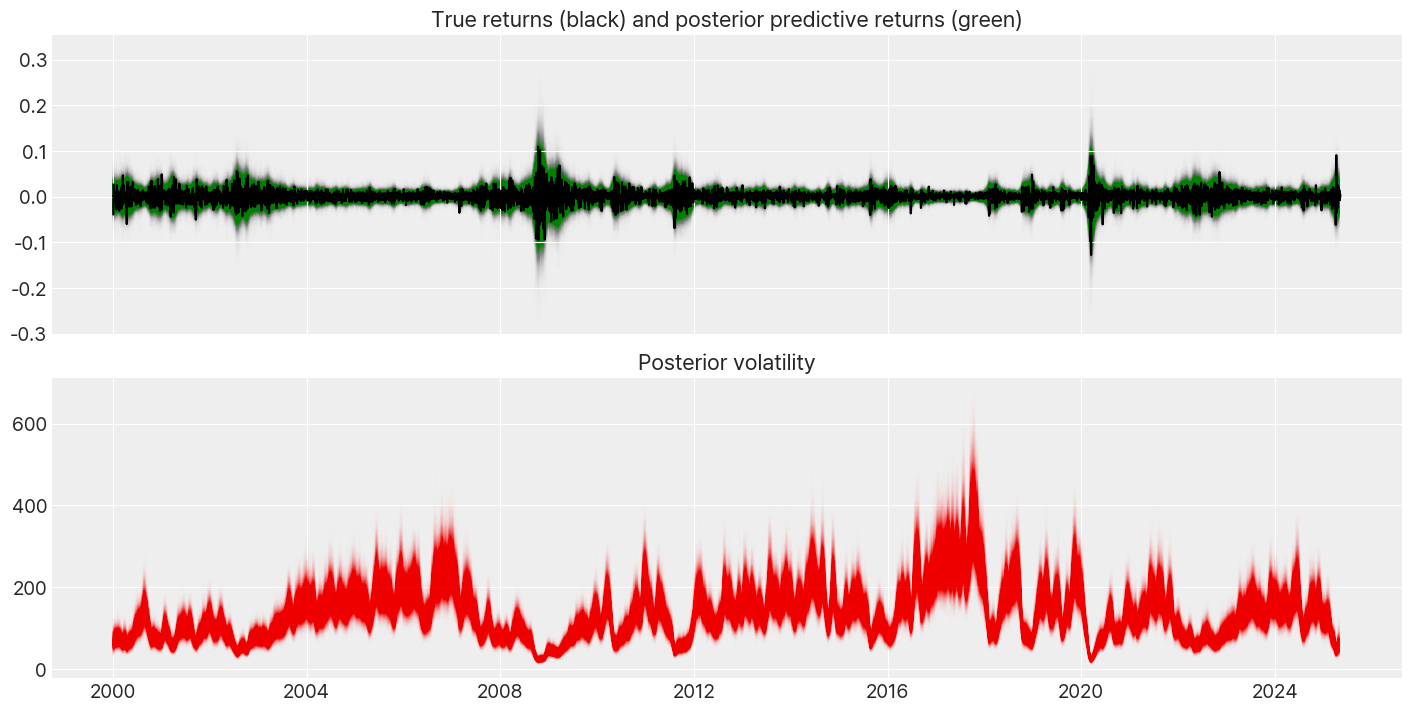

In [138]:
fig, axes = plt.subplots(nrows=2, figsize=(14, 7), sharex=True)
returns["log_change"].plot(ax=axes[0], color="black")

y_vals = posterior["volatility"].isel(pooled_chain=slice(None, None, 10))
x_vals = y_vals.time.astype(np.datetime64)
axes[1].plot(x_vals, y_vals, "r", alpha=0.002)

y_vals = posterior_predictive.posterior_predictive["returns"].stack(pooled_chain=("chain", "draw")).isel(pooled_chain=slice(None, None, 10))
x_vals = y_vals.time.astype(np.datetime64)
axes[0].plot(x_vals, y_vals, "g", alpha=0.002,
    zorder=-10)
axes[0].set_title("True returns (black) and posterior predictive returns (green)")
axes[1].set_title("Posterior volatility");
# plt.xlim(x_vals[-100], x_vals.max())

In [139]:
idata

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> prior
	> prior_predictive
	> observed_data

In [140]:
def create_forecast_model(data, idata, forecast_steps):
    """
    data: 원본 데이터프레임
    idata: 학습된 사후분포 (InferenceData 객체)
    forecast_steps: 예측 기간
    """
    import pymc as pm
    import numpy as np

    # 기존 모델의 마지막 시점 인덱스
    last_time = data.index[-1]
    forecast_dates = pd.date_range(start=last_time, periods=forecast_steps + 1, freq="D")[0:]

    with pm.Model(coords={"forecast_time": forecast_dates}) as forecast_model:
        # 사후분포로부터 mu와 step_size의 값을 추출
        step_size = pm.Exponential("step_size", 10)
        
        # 예측을 위한 Gaussian Random Walk
        # init_volatility_value = idata.posterior["log_volatility"].sel(time=last_time).mean().item()
        # init_volatility = pm.DiracDelta.dist(init_volatility_value)

        # 사후분포에서 마지막 시점의 log_volatility 샘플 추출
        last_log_volatility_samples = idata.posterior["log_volatility"].sel(time=last_time).values.flatten()
        
        # 사후분포에서의 샘플 수
        n_samples = len(last_log_volatility_samples)
        
        # 각 샘플이 선택될 확률 (동일한 확률)
        weights = np.ones(n_samples) / n_samples
        
        # Mixture 분포로 초기값 설정 (이름이 없는 분포 생성)
        init_volatility_dist = pm.Mixture.dist(
            w=weights,
            comp_dists=pm.Normal.dist(mu=last_log_volatility_samples, sigma=1e-3)  # sigma를 작게 하여 거의 확정적인 값처럼 설정
        )

        # Gaussian Random Walk 시작점으로 설정
        forecast_log_volatility = pm.GaussianRandomWalk(
            "forecast_log_volatility", 
            sigma=step_size, 
            init_dist=init_volatility_dist, 
            dims="forecast_time"
        )

        forecast_volatility = pm.Deterministic("forecast_volatility", pm.math.exp(forecast_log_volatility), dims="forecast_time")

        # Jump 관련 매개변수 정의 (로그 스케일에서 정의)
        # jump_prob = pm.Beta("jump_prob", alpha=2, beta=10)
        forecast_log_jump_size_mean = pm.Normal("forecast_log_jump_size_mean", mu=0, sigma=0.05)
        forecast_log_jump_size_sd = pm.HalfNormal("forecast_log_jump_size_sd", sigma=0.05)

        # 점프 여부 인디케이터
        forecast_jump_indicator = pm.Bernoulli("forecast_jump_indicator", p=0.0137, dims="forecast_time")
        forecast_log_jump_size = pm.Normal("forecast_log_jump_size", mu=forecast_log_jump_size_mean, sigma=forecast_log_jump_size_sd, dims="forecast_time")

        # 로그 스케일에서 점프 효과 추가
        forecast_log_volatility_with_jump = forecast_log_volatility + forecast_jump_indicator * forecast_log_jump_size

        # Student-T 분포의 파라미터 설정
        sigma = pm.Deterministic("sigma", pm.math.exp(-forecast_log_volatility_with_jump))
        nu = pm.Exponential("nu", 0.1)

        # 예측된 변동성에 따른 Student-T 분포 생성
        forecast_returns = pm.StudentT(
            "forecast_returns", 
            nu=nu, 
            sigma=sigma, 
            dims="forecast_time"
        )

    return forecast_model

forecast_model = create_forecast_model(train_data, idata=idata, forecast_steps=30)

In [141]:
with forecast_model:
    forecast_posterior = pm.sample_posterior_predictive(
        idata,
        var_names=["forecast_returns", "forecast_log_volatility", "forecast_volatility"],
        predictions=True,
        random_seed=rng
    )

Sampling: [forecast_jump_indicator, forecast_log_jump_size, forecast_log_jump_size_mean, forecast_log_jump_size_sd, forecast_log_volatility, forecast_returns]


Output()

In [142]:
idata

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> prior
	> prior_predictive
	> observed_data

In [143]:
forecast_posterior

Inference data with groups:
	> predictions

/tmp/ipykernel_8855/3123155524.py:15: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  axes[0].plot(x_vals, y_vals, "g", alpha=0.002,


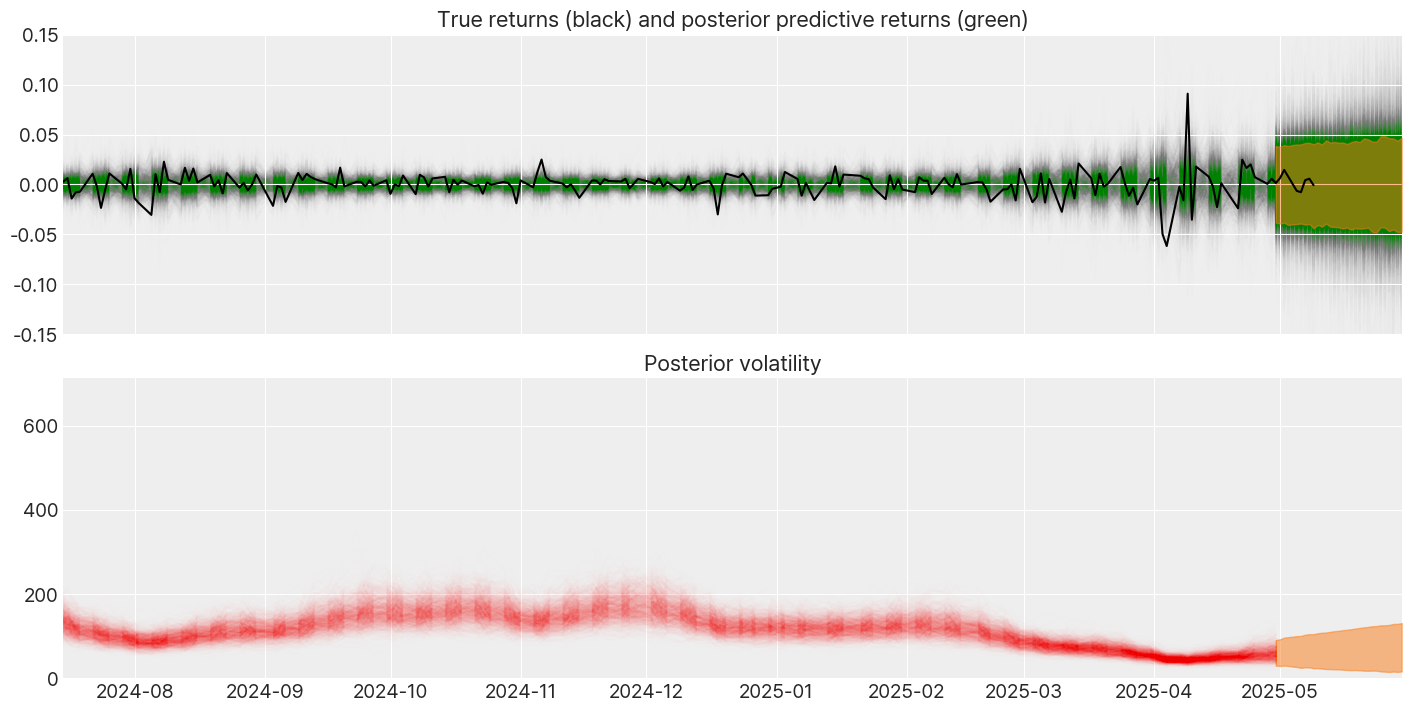

In [144]:
fig, axes = plt.subplots(nrows=2, figsize=(14, 7), sharex=True)
returns["log_change"].plot(ax=axes[0], color="black")

y_vals = posterior_predictive.posterior_predictive["returns"].stack(pooled_chain=("chain", "draw")).isel(pooled_chain=slice(None, None, 10))
x_vals1 = y_vals.time.astype(np.datetime64)
ax.plot(x_vals1, y_vals, "g", alpha=0.002,
    zorder=-10)

y_vals = posterior["volatility"].isel(pooled_chain=slice(None, None, 10))
x_vals = y_vals.time.astype(np.datetime64)
axes[1].plot(x_vals, y_vals, "r", alpha=0.002)

y_vals = posterior_predictive.posterior_predictive["returns"].stack(pooled_chain=("chain", "draw")).isel(pooled_chain=slice(None, None, 10))
x_vals = y_vals.time.astype(np.datetime64)
axes[0].plot(x_vals, y_vals, "g", alpha=0.002,
    zorder=-10)

stack = forecast_posterior.predictions["forecast_returns"].stack(pooled_chain=("chain", "draw"))
y_vals = stack.isel(pooled_chain=slice(None, None, 1))
x_vals = y_vals.forecast_time.astype(np.datetime64)
axes[0].plot(x_vals, y_vals, "g", alpha=0.002,
    zorder=-10)

az.plot_hdi(x=x_vals, y=forecast_posterior.predictions["forecast_returns"], ax=axes[0], smooth=False)
az.plot_hdi(x=x_vals, y=forecast_posterior.predictions["forecast_volatility"], ax=axes[1], smooth=False)
axes[1].set_xlim(x_vals1[-200], x_vals.max())
axes[0].set_ylim(-0.15, 0.15)
axes[1].set_ylim(bottom=0)

axes[0].set_title("True returns (black) and posterior predictive returns (green)")
axes[1].set_title("Posterior volatility");

/tmp/ipykernel_8855/1352027390.py:7: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(x_vals1, y_vals, "g", alpha=0.002,


(-0.15, 0.15)

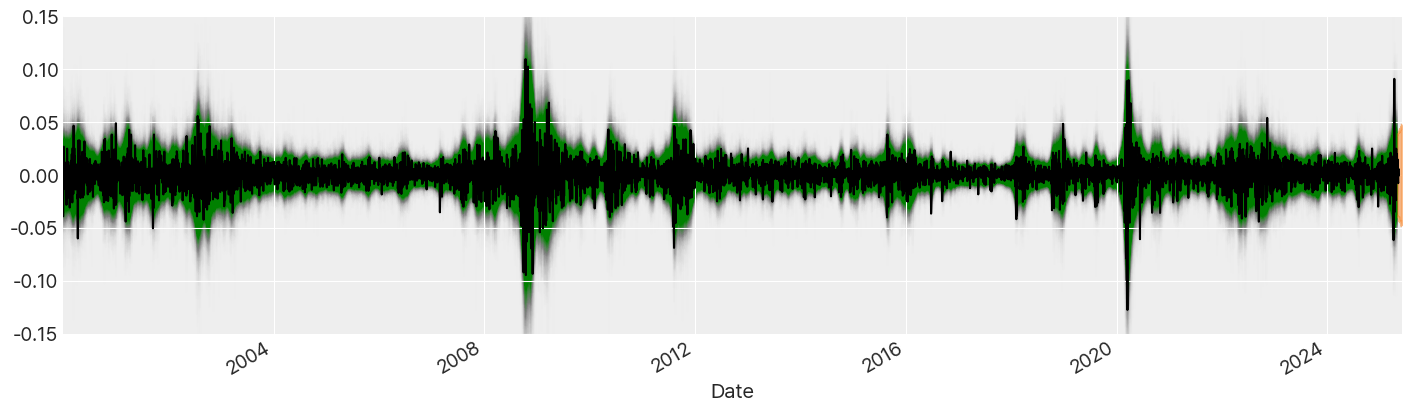

In [145]:
fig, ax = plt.subplots(figsize=(14, 4))
returns["log_change"].plot(ax=ax, color="black")

y_vals = posterior_predictive.posterior_predictive["returns"].stack(pooled_chain=("chain", "draw")).isel(pooled_chain=slice(None, None, 10))
# y_vals = np.exp(y_vals) - 1
x_vals1 = y_vals.time.astype(np.datetime64)
ax.plot(x_vals1, y_vals, "g", alpha=0.002,
    zorder=-10)
 
stack = forecast_posterior.predictions["forecast_returns"].stack(pooled_chain=("chain", "draw"))
y_vals = stack.isel(pooled_chain=slice(None, None, 10))
x_vals = y_vals.forecast_time.astype(np.datetime64)

az.plot_hdi(x=x_vals, y=forecast_posterior.predictions["forecast_returns"], ax=ax, smooth=False)

# ax.plot(x_vals, y_vals, "g", alpha=0.02);

ax.set_xlim(x_vals1.min(), x_vals.max())
ax.set_ylim(-0.15, 0.15)

